In [1]:
titanic = read.csv("https://peter.butka.website.tuke.sk/test/titanic2.csv")

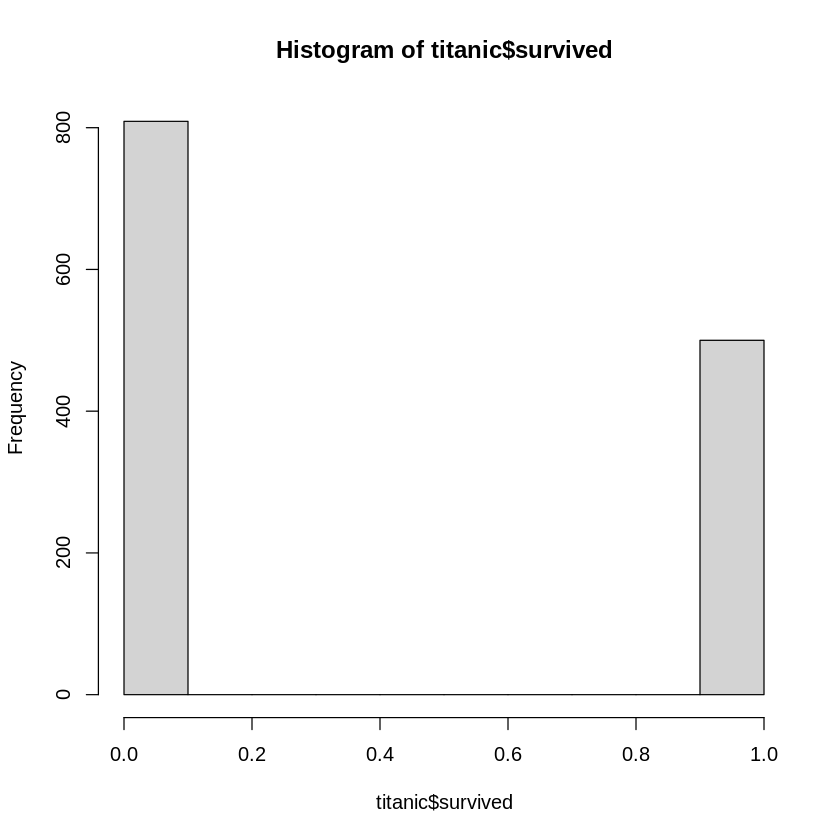

In [13]:
hist(titanic$survived)

In [2]:
head(titanic)

,pclass,survived,sex,age,sibsp,parch,ticket,fare,cabin,embarked,family,has_family,fare_ordinal,title,title_short,age_ordinal,deck
,<int>,<int>,<chr>,<dbl>,<int>,<int>,<chr>,<dbl>,<chr>,<chr>,<int>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>
1,1,1,female,29.00,0,0,24160,211.3375,B5,Southampton,0,False,most expensive,Miss,Miss,adult,B
2,1,1,male,0.92,1,2,113781,151.5500,C22 C26,Southampton,3,True,most expensive,Master,rare title,child,C
3,1,0,female,2.00,1,2,113781,151.5500,C22 C26,Southampton,3,True,most expensive,Miss,Miss,child,C
4,1,0,male,30.00,1,2,113781,151.5500,C22 C26,Southampton,3,True,most expensive,Mr,Mr,adult,C
5,1,0,female,25.00,1,2,113781,151.5500,C22 C26,Southampton,3,True,most expensive,Mrs,Mrs,adult,C
6,1,1,male,48.00,0,0,19952,26.5500,E12,Southampton,0,False,more expensive,Mr,Mr,adult,E


In [3]:
library(class)
library(caret)

Loading required package: ggplot2

Loading required package: lattice



In [4]:
#titanic$sex = ifelse(titanic$sex == 'male', 1, 0)
titanic$age_ordinal = as.factor(titanic$age_ordinal)
unique(titanic$fare_ordinal)
titanic$fare_ordinal = as.factor(titanic$fare_ordinal)

[1] "most expensive" "more expensive" "normal"

In [5]:
titanic$fare = (titanic$fare - min(titanic$fare))/(max(titanic$fare) - min(titanic$fare))
titanic$age = (titanic$age - min(titanic$age))/(max(titanic$age) - min(titanic$age))

In [6]:
ind = sample(2, nrow(titanic), replace = TRUE, prob=c(0.7, 0.3))
train.data = titanic[ind==1,]
test.data = titanic[ind==2,] 

In [8]:
train = train.data[, c("fare", "age")]
test = test.data[, c("fare", "age")]

trainS = train.data[, c("survived")]
testS = test.data[, c("survived")]

In [10]:
model = knn(train, test, trainS, k = 5)

In [11]:
res = table(model, testS)

In [12]:
confusionMatrix(res, mode="prec_recall")

Confusion Matrix and Statistics

     testS
model   0   1
    0 167  64
    1  66  74
                                          
               Accuracy : 0.6496          
                 95% CI : (0.5987, 0.6981)
    No Information Rate : 0.628           
    P-Value [Acc > NIR] : 0.2107          
                                          
                  Kappa : 0.2522          
                                          
 Mcnemar's Test P-Value : 0.9301          
                                          
              Precision : 0.7229          
                 Recall : 0.7167          
                     F1 : 0.7198          
             Prevalence : 0.6280          
         Detection Rate : 0.4501          
   Detection Prevalence : 0.6226          
      Balanced Accuracy : 0.6265          
                                          
       'Positive' Class : 0               
                                          